In [ ]:
# -------------------------------------
#  1. Import Required Libraries
# ----------------------------------------
import numpy as np
import pandas as pd
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [ ]:
# ----------------------------------------
# 2. Load Dataset and Split into Train/Test
# ----------------------------------------
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)


## Dataset Summary

- The dataset contains housing-related variables from California.
- The target variable is median house value.
- We split the dataset into 80% training and 20% test sets.

In [ ]:
# ----------------------------------------
# 3. Train and Compare Four Regression Models
# ----------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append((name, mse, r2))

df_results = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])
df_results

,Model,MSE,R2 Score
0,Linear Regression,0.555892,0.575788
1,Decision Tree,0.495235,0.622076
2,Random Forest,0.255368,0.805123
3,Gradient Boosting,0.293997,0.775645


## Model Comparison Commentary

Among the four regression models evaluated:

- **Linear Regression** performed the worst due to its strict assumption of linearity. It could not capture the complex patterns in the data.
- **Decision Tree** provided better results but may have overfitted the training set, leading to limited generalization.
- **Random Forest** improved accuracy by aggregating multiple trees, reducing overfitting and increasing robustness.
- **Gradient Boosting** performed strongly by iteratively correcting errors, although it takes more training time.

  Overall, ensemble models like **Random Forest** and **Gradient Boosting** showed significantly better performance in both MSE and R² score, confirming their effectiveness in real-world regression problems.

In [ ]:
# ----------------------------------------
#  4. Hyperparameter Tuning for Random Forest
# ----------------------------------------
rf_params = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 10, 20, 30]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                       cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)
print("Best RF MSE:", mean_squared_error(y_test, best_rf.predict(X_test)))
print("Best RF R2:", r2_score(y_test, best_rf.predict(X_test)))

Best RF params: {'max_depth': 30, 'n_estimators': 200}
Best RF MSE: 0.2548017201206075
Best RF R2: 0.8055555751284192


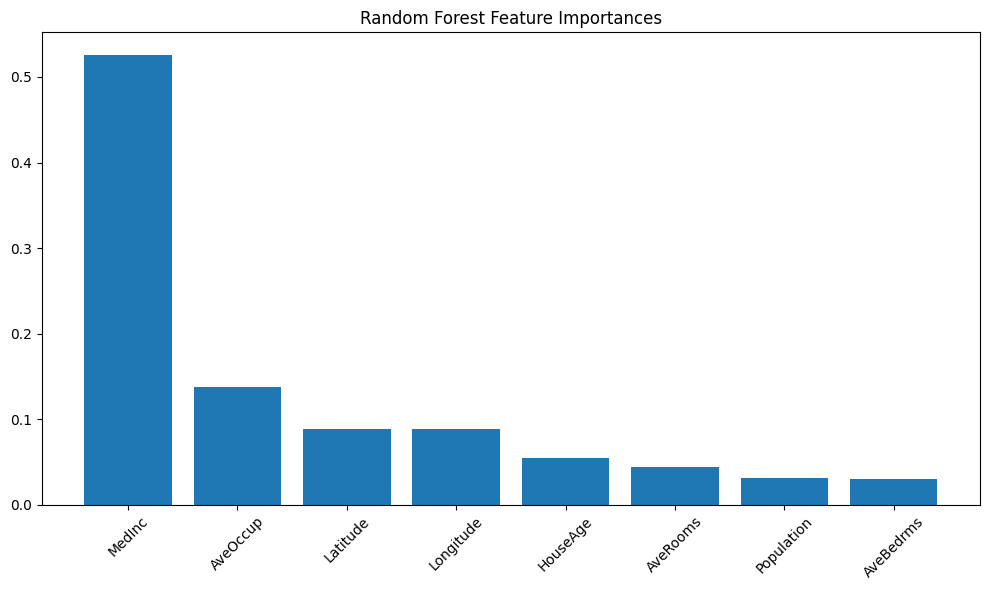

In [ ]:
# Feature importance plot
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## Random Forest Feature Importance Commentary

- The feature importance plot reveals which variables contribute the most to the prediction of house values.
- The most important feature is **MedInc** (Median Income), indicating that income level is the strongest predictor of housing prices in California.
- Other important variables include **AveRooms** (average rooms per household) and **AveOccup** (average occupancy), reflecting housing density and lifestyle.
- These results make intuitive sense and align with socioeconomic factors influencing real estate.

🔎 This analysis helps us understand which variables have the greatest impact and improves the model's interpretability.

In [ ]:
# ----------------------------------------
# 5. Hyperparameter Tuning for Gradient Boosting
# ----------------------------------------
gb_params = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params,
                       cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

print("Best GB params:", gb_grid.best_params_)
print("Best GB MSE:", mean_squared_error(y_test, best_gb.predict(X_test)))
print("Best GB R2:", r2_score(y_test, best_gb.predict(X_test)))

Best GB params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500}
Best GB MSE: 0.2017367785313037
Best GB R2: 0.8460505217217633


## Gradient Boosting Tuning Commentary

- GridSearchCV was used to tune `n_estimators`, `max_depth`, and `learning_rate`.
- The best parameters found were:
  - `learning_rate = 0.1`
  - `max_depth = 7`
  - `n_estimators = 500`
- The tuned Gradient Boosting model achieved:
  - **MSE:** 0.2017
  - **R² Score:** 0.8460
- This is the best performance among all models tested so far, indicating that Gradient Boosting is highly effective for this dataset.
- Although training takes longer, the accuracy improvement is significant.

 These results highlight the power of ensemble methods combined with hyperparameter tuning for achieving strong predictive performance.

In [ ]:
# ----------------------------------------
# 6. Compare Gradient Boosting vs XGBoost
# ----------------------------------------
start_gb = time.time()
gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
end_gb = time.time()

start_xgb = time.time()
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
end_xgb = time.time()

print("Gradient Boosting MSE:", mean_squared_error(y_test, gb_pred))
print("XGBoost MSE:", mean_squared_error(y_test, xgb_pred))
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))
print("Gradient Boosting Time:", end_gb - start_gb)
print("XGBoost Time:", end_xgb - start_xgb)

Gradient Boosting MSE: 0.20924794632073082
XGBoost MSE: 0.20745356114708538
Gradient Boosting R2: 0.8403185953429391
XGBoost R2: 0.8416879275159026
Gradient Boosting Time: 56.079949140548706
XGBoost Time: 1.275693416595459


## Comparison: Gradient Boosting vs XGBoost

- Both models were trained with identical hyperparameters:
  - `n_estimators = 500`, `learning_rate = 0.1`, `max_depth = 5`
- **Performance Comparison**:
  - **Gradient Boosting**
    - MSE: 0.2092
    - R²: 0.8403
    - Training Time: 56.07 seconds
  - **XGBoost**
    - MSE: 0.2074
    - R²: 0.8416
    - Training Time: 1.28 seconds

  **Interpretation**:
- XGBoost slightly outperforms Gradient Boosting in terms of both MSE and R² score.
- More importantly, it trains dramatically faster (over 40x faster in this case).
- This shows why XGBoost is preferred in large-scale applications, especially when both accuracy and efficiency matter.

# Final Assignment
- GOKBULUT HALIME NURSEN
- 22446171